# Imports

In [51]:
from model_builder import ModelBuilder
from model_utils import *
import random
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import colorsys
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
plt.rcParams["font.family"] = "Times New Roman"
import warnings
warnings.filterwarnings("ignore")

In [2]:
with open("config.json", "rb") as json_file:
    config = json.load(json_file)
config

{'becker': {'filename': 'beckerestimation_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'mean_pre_discussion_error',
   'mean_post_discussion_error',
   'median_pre_discussion_error',
   'median_post_discussion_error',
   'median_pre_discussion_error_pct',
   'median_post_discussion_error_pct',
   'mean_pre_discussion_error_pct',
   'mean_post_discussion_error_pct',
   'reverse_mean_post_discussion_error_pct',
   'reverse_median_post_discussion_error_pct',
   'question',
   'chatrooms',
   'trial_indx']},
 'csop': {'filename': 'csop_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'round_num',
   'round_index',
   'task_index',
   'complexity',
   'type',
   'social_perceptiveness',
   'skill',
   'normalized_score',
   'score',
   'duration',
   'efficiency']},
 'csopII': {'filename': 'csopII_output_conversation_level.csv',
  'cols_to_ignore': ['conversation_num',
   'batch_num',
   'vis_img',
   'int_verb',
   '

# Jury

In [3]:
# Define the basic model
juries_model = ModelBuilder(dataset_names = ["juries"])
juries_model.select_target(target=["majority_pct"])
juries_model.define_model(model_type = 'rf')

# CSOP (blended)

In [4]:
csop_blended_model = ModelBuilder(dataset_names = ["csop", "csopII"])
csop_blended_model.select_target(target=["efficiency", "efficiency"])
csop_blended_model.define_model(model_type = 'rf')

# DAT

In [5]:
dat_model = ModelBuilder(dataset_names = ["dat"])
dat_model.select_target(target=["efficiency"])
dat_model.define_model(model_type = 'rf')

# Estimation

In [6]:
estimation_blended_model = ModelBuilder(dataset_names = ["gurcay", "becker"])
estimation_blended_model.select_target(target=["mean_post_discussion_error_pct", "mean_post_discussion_error_pct"])
estimation_blended_model.define_model(model_type = 'rf')

# Create a PCA plot of the conversation features, colored by task

In [7]:
juries_data = pd.read_csv('../output/jury_output_conversation_level.csv')
csop_data = pd.read_csv('../output/csop_output_conversation_level.csv')
csopII_data = pd.read_csv('../output/csopII_output_conversation_level.csv')
dat_data = pd.read_csv('../output/dat_output_conversation_level.csv')
becker_data = pd.read_csv('../output/beckerestimation_output_conversation_level.csv')
gurcay_data = pd.read_csv('../output/gurcay2015estimation_output_conversation_level.csv')

In [8]:
juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data = drop_non_common_columns([juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data])

csop_blended_data = pd.concat([csop_data,csopII_data], axis=0)
estimation_blended_data = pd.concat([becker_data,gurcay_data], axis=0)

In [9]:
juries_data, csop_blended_data, dat_data, estimation_blended_data = get_numeric_cols([juries_data, csop_blended_data, dat_data, estimation_blended_data])

In [10]:
juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data = get_convs_with_min_value([juries_data, csop_blended_data, csop_data, csopII_data, dat_data, estimation_blended_data, becker_data, gurcay_data], "sum_num_messages", 10)

# PCA of Datasets

How do people "speak differently" across different tasks? Can we identify these different patterns of speaking just through clustering each conversation?

In [11]:
labels = ["Mock Jury", "Room Assignment Task", "Divergent Association Task", "Estimation"]
dataset_labels = ["Mock Jury", "CSOP", "CSOPII", "DAT", "Estimation (Becker)", "Estimation (Gurcay)"]

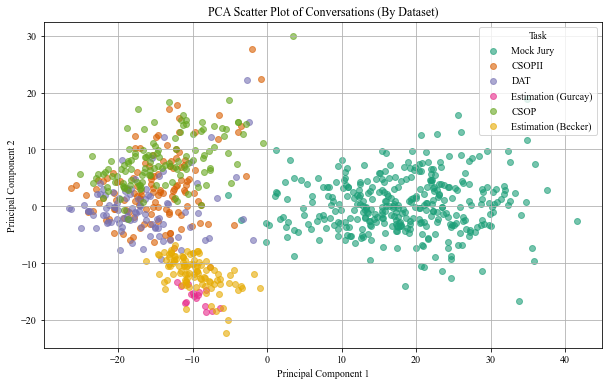

In [12]:
pca_results = plot_pca_of_dataframes(juries_data, csop_data, csopII_data, dat_data, becker_data, gurcay_data, labels=dataset_labels, title = "PCA Scatter Plot of Conversations (By Dataset)")

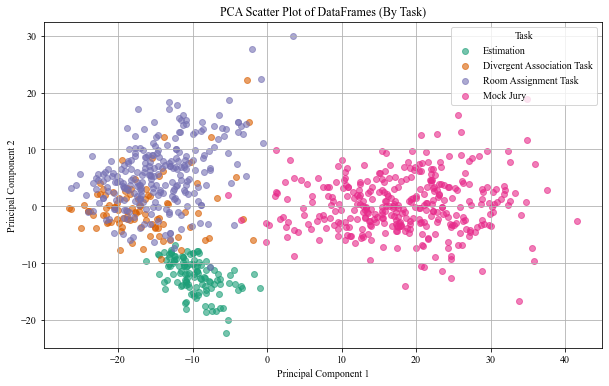

In [13]:
pca_results = plot_pca_of_dataframes(juries_data, csop_blended_data, dat_data, estimation_blended_data, labels=labels, title = "PCA Scatter Plot of DataFrames (By Task)")

In [14]:
pca_results.explained_variance_ratio_

array([0.2831507, 0.0547003])

In [15]:
examine_top_n_components(pca_results, n=10)

Top 5 Features for PC1:
                                     Feature       PC1       PC2   PC1_abs  \
667               average_user_avg_num_chars  0.055270 -0.003036  0.055270   
896  average_user_avg_nltk_english_stopwords  0.055269  0.000405  0.055269   
96                average_user_avg_num_words  0.055257 -0.001247  0.055257   
57            average_nltk_english_stopwords  0.055113  0.001155  0.055113   
109                        average_num_chars  0.055105 -0.002558  0.055105   
184                        average_num_words  0.055071 -0.000526  0.055071   
580               average_user_sum_num_chars  0.054864  0.034962  0.054864   
952  average_user_sum_nltk_english_stopwords  0.054745  0.034887  0.054745   
972          average_user_avg_cognitive_mech  0.054600 -0.001223  0.054600   
597                   average_user_avg_verbs  0.054541  0.000520  0.054541   

      PC2_abs  
667  0.003036  
896  0.000405  
96   0.001247  
57   0.001155  
109  0.002558  
184  0.000526  
580  

,Feature,PC1,PC2,PC1_abs,PC2_abs
0,max_user_sum_direct_start,0.026885,-0.006418,0.026885,0.006418
1,average_auxiliary_verbs,0.054519,0.000906,0.054519,0.000906
2,stdev_neutral_bert,-0.011128,0.045151,0.011128,0.045151
3,stdev_user_sum_past_tense,0.040301,0.002347,0.040301,0.002347
4,average_user_avg_textblob_subjectivity,0.008925,0.049467,0.008925,0.049467
...,...,...,...,...,...
1034,stdev_user_sum_anger,0.045688,0.001710,0.045688,0.001710
1035,min_user_avg_certainty,0.010043,0.021231,0.010043,0.021231
1036,min_user_sum_second_person,-0.003006,0.026954,0.003006,0.026954
1037,min_user_avg_deference,-0.003455,0.013241,0.003455,0.013241


PC 1 mostly captures *the quantity of how much people talk*.

PC 2 captures a combination of ideas: Type-Token Ratio, Number of Messages, Subjectivity, Positivity.

In general, Juries talk the most > Estimation second > CSOP / DAT last.

In general, Estimation has a lower PC2 (lower type/token ratio, lower positivity...)

## How much do all the other PC's tell us?
Answer: not a ton...

In [16]:
full_pca = get_pca_of_dataframes([juries_data, csop_blended_data, dat_data, estimation_blended_data], n_components = 10)

([<matplotlib.axis.XTick at 0x1358f86a0>,
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9')])

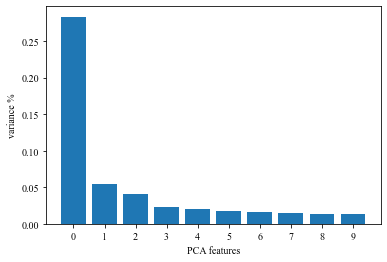

In [17]:
var = full_pca.explained_variance_ratio_
plt.bar(list(range(var.shape[0])),var)
feature = range(full_pca.n_components_)
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(feature)

# PCA of Features

Can we now model each feature as a point, and see how the different features relate to each other?

(The following code generates an interactive PCA plot, but opens in a brower window.)

Columns with NaN values: ['min_inhibition', 'min_content_word_accommodation', 'min_user_avg_indicative', 'min_user_avg_direct_question', 'min_1st_person_pl.', 'min_user_sum_subjunctive', 'min_hashedge', 'min_user_sum_NTRI', 'min_first_pronouns_proportion', 'min_percept', 'min_family', 'min_please', 'min_user_avg_sexual', 'min_user_sum_please_start', 'min_user_sum_gratitude', 'min_article', 'min_hear', 'min_user_avg_factuality', 'min_hedges', 'min_see', 'min_user_avg_please', 'min_user_sum_indirect_(btw)', 'min_2nd_person', 'min_negative_affect', 'min_past_tense', 'min_insight', 'min_friends', 'min_user_avg_anxiety', 'min_positive_words', 'min_user_avg_death', 'min_swear', 'min_user_avg_NTRI', 'min_home', 'stdev_num_messages', 'max_word_TTR', 'max_num_messages', 'min_subjunctive', 'min_sexual', 'min_gratitude', 'min_haspositive', 'min_relative', 'min_first_person_plural', 'min_first_person_singular', 'min_conjunction', 'average_num_messages', 'min_2nd_person_start', 'min_indirect_(greet

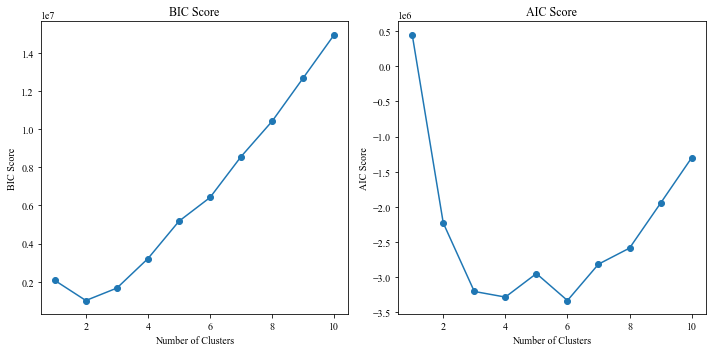

In [18]:
visualize_feature_clusters([juries_data, csop_blended_data, dat_data, estimation_blended_data], use_aic = True, title = "PCA Scatter Plot of Conversational Features")

Columns with NaN values: ['min_inhibition', 'min_content_word_accommodation', 'min_user_avg_indicative', 'min_user_avg_direct_question', 'min_1st_person_pl.', 'min_user_sum_subjunctive', 'min_hashedge', 'min_user_sum_NTRI', 'min_first_pronouns_proportion', 'min_percept', 'min_family', 'min_please', 'min_user_avg_sexual', 'min_user_sum_please_start', 'min_user_sum_gratitude', 'min_article', 'min_hear', 'min_user_avg_factuality', 'min_hedges', 'min_see', 'min_user_avg_please', 'min_user_sum_indirect_(btw)', 'min_2nd_person', 'min_negative_affect', 'min_past_tense', 'min_insight', 'min_friends', 'min_user_avg_anxiety', 'min_positive_words', 'min_user_avg_death', 'min_swear', 'min_user_avg_NTRI', 'min_home', 'stdev_num_messages', 'max_word_TTR', 'max_num_messages', 'min_subjunctive', 'min_sexual', 'min_gratitude', 'min_haspositive', 'min_relative', 'min_first_person_plural', 'min_first_person_singular', 'min_conjunction', 'average_num_messages', 'min_2nd_person_start', 'min_indirect_(greet

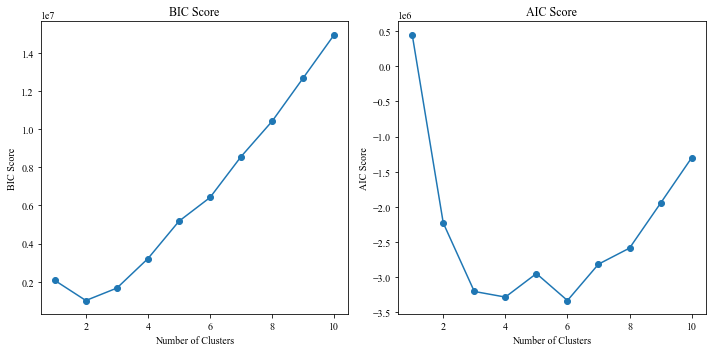

In [25]:
# Get more insight into the clusters!
all_data = pd.concat([juries_data, csop_blended_data, dat_data, estimation_blended_data], join = 'inner', ignore_index = True)

'''
The below reproduces the code from inside the plotting function, but gives us access to the actual cluster labels to 
play around with!
'''

# Normalize (Across all tasks)
columns_to_normalize = [col for col in all_data.columns if col != 'task_name']
normalized_df = all_data.copy()
normalized_df[columns_to_normalize] = normalized_df[columns_to_normalize].transform(lambda x: (x - x.mean()) / x.std())

# Drop NA columns
nan_cols, nan_rows = check_na_rows_cols(normalized_df)
normalized_df = normalized_df.drop(nan_cols, axis = 1)

normalized_data_transposed = normalized_df.drop(["task_name"], axis=1).T

# Get Clusters (using GMM) for the data, on the full-dimensional dataset.
cluster_labels = get_gaussian_mixture_clustering(normalized_data_transposed, use_aic=True)

In [32]:
normalized_data_transposed["cluster"] = cluster_labels

In [60]:
def explore_clustered_features(df, num_closest=5):
    unique_clusters = df['cluster'].unique()
    nearest_points_df = pd.DataFrame()

    for cluster_label in unique_clusters:
        cluster_data = df[df['cluster'] == cluster_label]
        features = cluster_data.drop(columns=['cluster'])

        centroid = features.mean(axis=0)
        similarity_scores = cosine_similarity([centroid], features).flatten()

        # Get the num_closest data points with highest similarity
        nearest_indices = np.argsort(similarity_scores)[-num_closest:]
        nearest_cluster_points = cluster_data.iloc[nearest_indices]
        nearest_points_df = pd.concat([nearest_points_df, nearest_cluster_points])

    return nearest_points_df

Explore the top n (=10) features per cluster, by examining the closest features to the cluster centroid. What is "most representative" of the cluster?

TODO: these clusters are not super interpretable...

In [82]:
top_10_features_per_cluster = explore_clustered_features(normalized_data_transposed, num_closest = 10)
pca = PCA(n_components=2)
pca_top = pca.fit_transform(top_10_features_per_cluster.drop(["cluster"], axis = 1))

# Create a new DataFrame with the PC scores and row names
pca_df = pd.DataFrame(data=pca_top, columns=["PC1", "PC2"], index=top_10_features_per_cluster.index)
pca_df["cluster"] = top_10_features_per_cluster["cluster"]

generate_interactive_feature_plot(pca_df, "PCA of Top 5 Features Per Cluster")

## PCA of User Features

In [19]:
jury_users = pd.read_csv('../output/jury_output_user_level.csv')
csop_users = pd.read_csv('../output/csop_output_user_level.csv')
csopII_users = pd.read_csv('../output/csopII_output_user_level.csv')
dat_users = pd.read_csv('../output/dat_output_user_level.csv')
becker_estimation_users = pd.read_csv('../output/beckerestimation_output_user_level.csv')
gurcay_estimation_users = pd.read_csv('../output/gurcay2015estimation_output_user_level.csv')

In [20]:
# Get Non-Empty Conversations
jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users = get_users_in_nonempty_conversations([jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users])

In [21]:
# Preprocess the user dataframes
jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users = drop_non_common_columns([jury_users, csop_users, csopII_users, dat_users, becker_estimation_users, gurcay_estimation_users])

csop_blended_users = pd.concat([csop_users,csopII_users], axis=0)
estimation_blended_users = pd.concat([becker_estimation_users,gurcay_estimation_users], axis=0)

# Then get only the numeric columns
jury_users, csop_blended_users, dat_users, estimation_blended_users = get_numeric_cols([jury_users, csop_blended_users, dat_users, estimation_blended_users])

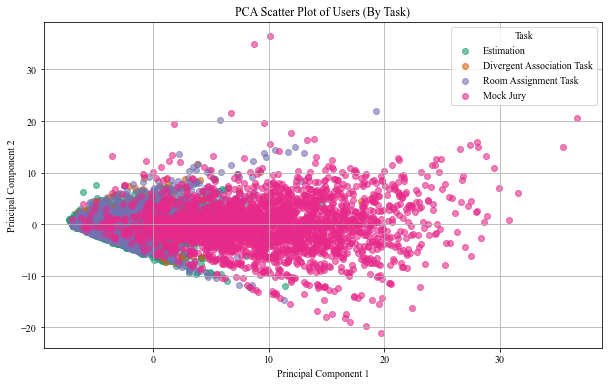

In [22]:
pca_results_users = plot_pca_of_dataframes(jury_users, csop_blended_users, dat_users, estimation_blended_users, labels=labels, title = "PCA Scatter Plot of Users (By Task)")

In [23]:
pca_results_users.explained_variance_ratio_

array([0.26327829, 0.05470521])

In [24]:
examine_top_n_components(pca_results_users, n=10)

Top 5 Features for PC1:
                        Feature       PC1       PC2   PC1_abs   PC2_abs
80   sum_nltk_english_stopwords  0.136225  0.061512  0.136225  0.061512
137               sum_num_chars  0.136074  0.070750  0.136074  0.070750
112               sum_num_words  0.135995  0.077420  0.135995  0.077420
163          sum_cognitive_mech  0.134440  0.057344  0.134440  0.057344
125                   sum_verbs  0.133991  0.060913  0.133991  0.060913
164         sum_auxiliary_verbs  0.131312  0.058547  0.131312  0.058547
51                   sum_social  0.127877  0.046320  0.127877  0.046320
78            sum_present_tense  0.127853  0.069428  0.127853  0.069428
2               sum_preposition  0.126775  0.046809  0.126775  0.046809
117           average_num_words  0.124728 -0.133995  0.124728  0.133995

Top 5 Features for PC2:
                                Feature       PC1       PC2   PC1_abs  \
41                         sum_word_TTR  0.071218  0.233086  0.071218   
168          

,Feature,PC1,PC2,PC1_abs,PC2_abs
0,average_tentativeness,0.066699,-0.096985,0.066699,0.096985
1,average_auxiliary_verbs,0.114350,-0.118986,0.114350,0.118986
2,sum_preposition,0.126775,0.046809,0.126775,0.046809
3,average_hedge_naive,0.029349,-0.034694,0.029349,0.034694
4,sum_positive_affect,0.092731,0.128818,0.092731,0.128818
...,...,...,...,...,...
182,average_hashedge,0.074760,-0.103299,0.074760,0.103299
183,average_money,0.005375,-0.027008,0.005375,0.027008
184,sum_1st_person,0.083987,0.057437,0.083987,0.057437
185,average_1st_person,0.054459,-0.063200,0.054459,0.063200
